In [10]:
from plot_functions import *
from obs_functions import *
from trace_functions import *
import matplotlib.pyplot as plt
from matplotlib.widgets import CheckButtons  # Add this import statement
from matplotlib.widgets import Slider

# File paths
obstFile = '/home/graal/ros2_ws/log/avoidance_logs/obstacles/obstacles.txt'
completeNodes = '/home/graal/ros2_ws/log/avoidance_logs/nodes/completePathNodes.txt'
failedNodes = '/home/graal/ros2_ws/log/avoidance_logs/nodes/failedPathNodes.txt'
validNodes = '/home/graal/ros2_ws/log/avoidance_logs/nodes/validPathNodes.txt'
notValidNodes = '/home/graal/ros2_ws/log/avoidance_logs/nodes/notValidPathNodes.txt'

traces = parse_trace_data(completeNodes)
obstacles_df = parse_obstacle_file(obstFile)

In [4]:
import matplotlib
matplotlib.use('TkAgg')  # Ensure GUI backend

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Polygon
from matplotlib.widgets import Slider

# --- Setup figure and axis ---
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

# --- Add static circle ---
circle = Circle((0, 0), radius=1, color='blue', fill=False, linewidth=2)
ax.add_patch(circle)

# --- Add dynamic shape ---
shape_patch = Polygon([[0, 0]], closed=True, color='red', fill=False, linewidth=2)
ax.add_patch(shape_patch)

# --- Set axis limits and aspect ---
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')

# --- Create slider ---
ax_slider = plt.axes([0.25, 0.1, 0.5, 0.03])
slider = Slider(ax_slider, 'Shape', 0, 1, valinit=0, valstep=1)

# --- Define shapes ---
def get_square():
    return np.array([[-1, -1], [-1, 1], [1, 1], [1, -1]])

def get_triangle():
    return np.array([[-1, -1], [1, -1], [0, 1]])

# --- Slider callback function ---
def update(val):
    coords = get_square() if slider.val == 0 else get_triangle()
    shape_patch.set_xy(coords)
    fig.canvas.draw_idle()

slider.on_changed(update)
update(0)

plt.show()


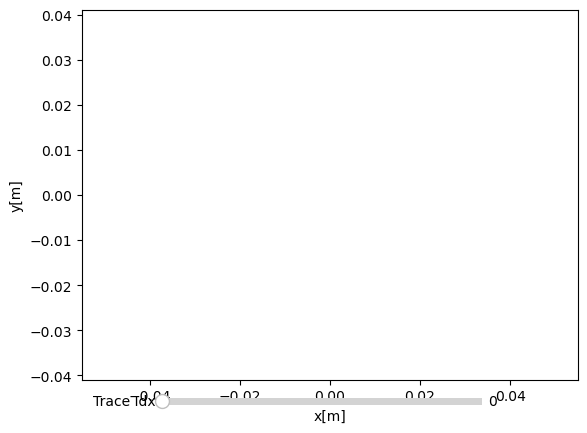

In [8]:



fig, ax = plot_init()

# Slider axis and slider itself
slider_ax = plt.axes([0.25, 0.05, 0.5, 0.03], facecolor='lightgoldenrodyellow')
slider = Slider(slider_ax, 'Trace Idx', 0, len(traces) - 1, valinit=0, valstep=1)

# Update function when slider is moved
def update(val):
    idx = int(slider.val)
    plot_trace(get_traces(traces, idx), ax=ax, color ='red')

slider.on_changed(update)


plt.show()
#plt.savefig('/home/graal/ros2_ws/log/avoidance_logs/sample.pdf')




In [2]:
def interactive_trace_plot(traces, save_path=None):
    """
    Create an interactive plot with slider to select trace index.
    Optionally, save final figure to `save_path`.
    """
    fig, ax = plot_init()
    
    # Initial trace plot (first one)
    plot_trace(traces[0], ax)
    
    # Slider axis and slider itself
    slider_ax = plt.axes([0.25, 0.05, 0.5, 0.03], facecolor='lightgoldenrodyellow')
    slider = Slider(slider_ax, 'Trace Idx', 0, len(traces) - 1, valinit=0, valstep=1)
    
    # Update function when slider is moved
    def update(val):
        idx = int(slider.val)
        plot_trace(traces[idx], ax)
    
    slider.on_changed(update)
    
    # Show plot
    plt.show()

    # Save plot if save_path provided
    if save_path:
        fig.savefig(save_path)
        print(f"Plot saved to {save_path}")

In [11]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display

# --- Assumed functions and data ---
# These should already be defined in your environment.
# For example:
#
# def get_obstacle_row_by_name(df, obstacle_name):
#     # Return the row corresponding to the obstacle_name (or None if not found)
#     return df[df['obstacle_id'] == obstacle_name].iloc[0] if obstacle_name in df['obstacle_id'].values else None
#
# def plot_obstacle(row, t, color):
#     # Plot the obstacle using its data (row) at time t with the given color.
#     # (Your implementation might plot a rectangle or similar.)
#     plt.scatter(row['x'] + float(row['vel_x'])*t, row['y'] + float(row['vel_y'])*t,
#                 color=color, s=100, label=row['obstacle_id'])
#
# obstacles_df: A DataFrame that must contain at least:
#   - 'obstacle_id': unique IDs for obstacles
#   - 'x', 'y': center coordinates
#   - 'vel_x', 'vel_y': velocities (if used for computing new positions)
#
# -----------------------------------

# Create a list of obstacle names (unique obstacle IDs)
obstacle_names = obstacles_df['obstacle_id'].unique()

# Create a dictionary to hold controls for each obstacle.
controls = {}
for obst in obstacle_names:
    controls[obst] = {
         'checkbox': widgets.Checkbox(value=True, description=''),
         'text': widgets.Text(value='', placeholder='Enter time', description=''),
         'slider': widgets.FloatSlider(value=0, min=0, max=1000, step=1, description=''),
         'clear_button': widgets.Button(description='Clear')
         # We add a flag for the slider command:
         ,'slider_active': True
    }

# Create an output widget for the plot.
plot_output = widgets.Output()

def update_plot(change=None):
    with plot_output:
        plot_output.clear_output(wait=True)
        plt.figure(figsize=(8, 8))
        
        # For each obstacle, plot according to the commands:
        for obst in obstacle_names:
            row = get_obstacle_row_by_name(obstacles_df, obst)
            if row is None:
                continue
            # Command 1: Original position via checkbox (blue, t=0)
            if controls[obst]['checkbox'].value:
                plot_obstacle(row, t=0, color='blue')
            # Command 2: Text box time (red) – if a valid time is given.
            text_val = controls[obst]['text'].value
            try:
                t_text = float(text_val)
                plot_obstacle(row, t=t_text, color='red')
            except ValueError:
                pass  # If empty or invalid, do nothing.
            # Command 3: Slider time (purple) – only if slider is "active"
            if controls[obst]['slider_active']:
                t_slider = controls[obst]['slider'].value
                plot_obstacle(row, t=t_slider, color='purple')
                
        plt.xlabel('X Position')
        plt.ylabel('Y Position')
        plt.title('Obstacle Rectangles')
        plt.gca().set_aspect('equal', adjustable='box')
        plt.legend()
        plt.show()

# Callback for slider changes: when the slider moves, re-enable slider drawing.
def on_slider_change(change, obst):
    controls[obst]['slider_active'] = True
    update_plot()

# Callback for the clear button: disable the slider drawing and reset its value.
def on_clear_button_click(b, obst):
    controls[obst]['slider_active'] = False
    controls[obst]['slider'].value = 0
    update_plot()

# Attach observers for each control per obstacle.
for obst in obstacle_names:
    controls[obst]['checkbox'].observe(update_plot, names='value')
    controls[obst]['text'].observe(update_plot, names='value')
    # For the slider, use a lambda to pass the obstacle id.
    controls[obst]['slider'].observe(lambda change, obst=obst: on_slider_change(change, obst), names='value')
    controls[obst]['clear_button'].on_click(lambda b, obst=obst: on_clear_button_click(b, obst))

# Build a "table" of controls.
# Create a header row.
header = widgets.HBox([
    widgets.Label(value='Obstacle', layout=widgets.Layout(width='100px')),
    widgets.Label(value='Original', layout=widgets.Layout(width='80px')),
    widgets.Label(value='Text Time', layout=widgets.Layout(width='150px')),
    widgets.Label(value='Slider Time', layout=widgets.Layout(width='200px')),
    widgets.Label(value='Clear Slider', layout=widgets.Layout(width='100px'))
])

# Build one row per obstacle.
rows = []
for obst in obstacle_names:
    row_widget = widgets.HBox([
        widgets.Label(value=str(obst), layout=widgets.Layout(width='100px')),
        controls[obst]['checkbox'],
        controls[obst]['text'],
        controls[obst]['slider'],
        controls[obst]['clear_button']
    ])
    rows.append(row_widget)

table = widgets.VBox([header] + rows)

# Display the table and the plot output.
display(table, plot_output)

# Initial plot rendering.
update_plot()


Output()

In [ ]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
from ipywidgets import interactive_output

# Assuming `obstacles_df`, `plot_obstacle`, and `get_obstacle_row_by_name` are defined

# Create a list of obstacle names (unique obstacle IDs)
obstacle_names = obstacles_df['obstacle_id'].unique()

# Create checkboxes for each obstacle
checkboxes = {obstacle: widgets.Checkbox(value=True, description=obstacle) for obstacle in obstacle_names}

# Function to plot obstacles based on checkbox states.
# It now accepts keyword arguments corresponding to each checkbox.
def plot_obstacles(**kwargs):
    plt.figure(figsize=(8, 8))
    
    # Plot all obstacles at t=0 with blue if the corresponding checkbox is checked.
    for obstacle, checked in kwargs.items():
        if checked:
            obstacle_row = get_obstacle_row_by_name(obstacles_df, obstacle)
            if obstacle_row is not None:
                plot_obstacle(obstacle_row, t=0, color='blue')
    
    # Additionally, always plot the 'unknown0' obstacle at t=1000 in green.
    obstacle_row = get_obstacle_row_by_name(obstacles_df, 'unknown0')
    if obstacle_row is not None:
        plot_obstacle(obstacle_row, t=1000, color='green')
    
    # Set labels, title, and equal scaling.
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.title('Obstacle Rectangles')
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.show()

# Create a VBox widget to display the checkboxes vertically.
ui = widgets.VBox(list(checkboxes.values()))

# Use interactive_output to bind the checkboxes to our plotting function.
out = interactive_output(plot_obstacles, {obstacle: checkboxes[obstacle] for obstacle in obstacle_names})

# Display the controls and output.
display(ui, out)


In [ ]:
import matplotlib.pyplot as plt

# Non-interactive example
plt.figure(figsize=(8, 8))

# Plot all obstacles at t=0 with a specific color
for idx, row in obstacles_df.iterrows():
    plot_obstacle(row, t=0, color='blue')  # Plot obstacle at time t=0 with blue color

# Get the row for a specific obstacle
obstacle_name = 'unknown0'  # Example obstacle ID
obstacle_row = get_obstacle_row_by_name(obstacles_df, obstacle_name)
plot_obstacle(obstacle_row, t=1000, color='green')  # Plot 'unknown0' obstacle at time t=1000 with green color

# Set labels and title
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Obstacle Rectangles')

# Ensure equal axis scaling
plt.gca().set_aspect('equal', adjustable='box')

# Display the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Assume obstacles_df, compute_obstacle_position_at_time, and plot_obstacle are defined

obstacle_options = list(obstacles_df['obstacle_id'].unique())

obstacle_select = widgets.SelectMultiple(
    options=obstacle_options,
    value=tuple(obstacle_options),
    description='Obstacles'
)

time_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=2000,
    step=100,
    description='Time:',
    continuous_update=False
)

def update_plot(selected_obstacles, time):
    plt.clf()
    plt.figure(figsize=(8, 8))
    for obs in selected_obstacles:
        row = compute_obstacle_position_at_time(obstacles_df, obs, time)
        plot_obstacle(row, color='green', alpha=0.5, label=f"Obstacle {obs} t({time})")
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.title('Obstacle Rectangles')
    plt.gca().set_aspect('equal', adjustable='box')
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.show()

ui = widgets.VBox([obstacle_select, time_slider])
out = widgets.interactive_output(update_plot, {'selected_obstacles': obstacle_select, 'time': time_slider})
display(ui, out)


In [ ]:
print(obstacles_df)
print(trace_df)

In [ ]:
obstacles_df.info(verbose=True)